[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter3_seminar_notebook.ipynb)

# Statistics of Financial Markets — Seminar 3: α-stable distributions

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 3: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with a measure of precision and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- The stable law: characteristic function, FFT density (`StableGrid`), simulation (`rstable`, Chambers–Mallows–Stuck).
- Estimation: `mcculloch` (McCulloch, 1986), `stable_mle` (maximum likelihood, S0), `fit_models` (Normal, Student-t, stable).
- Helpers for Part A and the bootstrap of the McCulloch α.

In [ ]:
START = '2000-01-01'
ASSETS = ['bet', 'sp500', 'dax', 'btc']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F'}
MODEL_COL = {'Normal': '#CD0000', 'Student-t': '#2E7D32', 'Stable': '#1A3A6E', 'Data': '#B5853F'}
SEED = 2026
SEM_START = '2000-01-01'


def stable_cf(t, alpha, beta, gamma=1.0, delta=0.0, param=0):
    """Characteristic function E exp(itX) of S(alpha, beta, gamma, delta; param), Nolan's S0 (param=0) or S1."""
    t = np.asarray(t, float)
    a = np.abs(gamma * t)
    if alpha != 1:
        tan = np.tan(np.pi * alpha / 2)
        if param == 0:      # -|gt|^a [1 + i b tan(pi a/2) sign(t) (|gt|^(1-a) - 1)], written without 0^(1-a)
            psi = -a ** alpha - 1j * beta * tan * (gamma * t - np.sign(t) * a ** alpha)
        else:               # -|gt|^a [1 - i b tan(pi a/2) sign(t)]
            psi = -a ** alpha * (1 - 1j * beta * tan * np.sign(t))
    else:
        arg = a if param == 0 else np.abs(t)
        lg = np.log(np.where(arg > 0, arg, 1.0))
        psi = -a * (1 + 1j * beta * (2 / np.pi) * np.sign(t) * lg)
    return np.exp(psi + 1j * delta * t)


def s1_to_s0(alpha, beta, gamma, delta1):
    """Location in S0 from the location in S1 (Nolan, 2020): only delta changes."""
    if alpha != 1:
        return delta1 + beta * gamma * np.tan(np.pi * alpha / 2)
    return delta1 + beta * (2 / np.pi) * gamma * np.log(gamma)


def s0_to_s1(alpha, beta, gamma, delta0):
    """Location in S1 from the location in S0."""
    if alpha != 1:
        return delta0 - beta * gamma * np.tan(np.pi * alpha / 2)
    return delta0 - beta * (2 / np.pi) * gamma * np.log(gamma)


class StableGrid:
    """Density and distribution function of the standard S0(alpha, beta, 1, 0) law on a fine grid, by FFT
    inversion of the characteristic function, f(x) = (1/2pi) int phi(t) exp(-itx) dt (Mittnik et al., 1999).
    Grid step h = 0.01 on [-327.68, 327.67]; the power-law tail approximation is used beyond the grid."""

    def __init__(self, alpha, beta, h=0.01, N=2 ** 16):
        k = np.fft.fftfreq(N, d=1.0 / N)                        # 0, 1, ..., N/2-1, -N/2, ..., -1
        dt = 2 * np.pi / (N * h)
        phi = stable_cf(k * dt, alpha, beta, 1.0, 0.0, 0) * np.where(k % 2 == 0, 1.0, -1.0)
        f = np.real(np.fft.fft(phi)) * dt / (2 * np.pi)
        self.alpha, self.beta, self.h = alpha, beta, h
        self.x = (np.arange(N) - N / 2) * h
        self.f = np.maximum(f, 1e-300)
        self.logf = np.log(self.f)
        # tail constant: P(X > x) ~ c_alpha (1 + beta) x^(-alpha), c_alpha = Gamma(alpha) sin(pi alpha / 2) / pi
        from scipy.special import gamma as G
        self.c = 0.0 if alpha >= 2 else G(alpha) * np.sin(np.pi * alpha / 2) / np.pi
        left = self.c * (1 - beta) * abs(self.x[0]) ** (-alpha) if alpha < 2 else 0.0
        right = self.c * (1 + beta) * self.x[-1] ** (-alpha) if alpha < 2 else 0.0
        cells = 0.5 * (self.f[1:] + self.f[:-1]) * h
        self.F = np.clip(left + np.concatenate([[0.0], np.cumsum(cells)]), 0.0, 1.0)           # P(X <= x), from the left
        self.S = np.clip(right + np.concatenate([np.cumsum(cells[::-1])[::-1], [0.0]]), 0.0, 1.0)  # P(X > x), from the right

    def pdf(self, z):
        z = np.asarray(z, float)
        out = np.exp(np.interp(z, self.x, self.logf))
        far = np.abs(z) > self.x[-1]
        if far.any() and self.alpha < 2:
            out[far] = self.alpha * self.c * (1 + np.sign(z[far]) * self.beta) * np.abs(z[far]) ** (-self.alpha - 1)
        return out

    def cdf(self, z):
        z = np.asarray(z, float)
        return np.where(z <= 0, np.interp(z, self.x, self.F), 1 - np.interp(z, self.x, self.S))

    def sf(self, z):
        return 1 - self.cdf(z) if np.ndim(z) == 0 else np.where(np.asarray(z) > 0, np.interp(z, self.x, self.S), 1 - self.cdf(z))

    def ppf(self, p):
        i = np.searchsorted(self.F, 1e-12) if self.F[0] < 1e-12 else 0
        return np.interp(p, self.F[i:], self.x[i:])


def stable_pdf(x, alpha, beta, gamma=1.0, delta=0.0, param=0):
    """Density of S(alpha, beta, gamma, delta; param) on any points x (FFT grid, see StableGrid)."""
    d0 = delta if param == 0 else s1_to_s0(alpha, beta, gamma, delta)
    return StableGrid(alpha, beta).pdf((np.asarray(x, float) - d0) / gamma) / gamma


def rstable(n, alpha, beta=0.0, gamma=1.0, delta=0.0, param=1, rng=None):
    """n draws of S(alpha, beta, gamma, delta) by the Chambers-Mallows-Stuck method.
    V ~ Uniform(-pi/2, pi/2), W ~ Exponential(1), independent; the formula gives S1(alpha, beta, 1, 0)."""
    rng = np.random.default_rng(rng)
    V = rng.uniform(-np.pi / 2, np.pi / 2, n)
    W = rng.exponential(1.0, n)
    if alpha != 1:
        B = np.arctan(beta * np.tan(np.pi * alpha / 2)) / alpha
        S = (1 + beta ** 2 * np.tan(np.pi * alpha / 2) ** 2) ** (1 / (2 * alpha))
        X = (S * np.sin(alpha * (V + B)) / np.cos(V) ** (1 / alpha)
             * (np.cos(V - alpha * (V + B)) / W) ** ((1 - alpha) / alpha))
        Y = gamma * X + (delta if param == 1 else delta - beta * gamma * np.tan(np.pi * alpha / 2))
    else:
        X = (2 / np.pi) * ((np.pi / 2 + beta * V) * np.tan(V)
                           - beta * np.log((np.pi / 2) * W * np.cos(V) / (np.pi / 2 + beta * V)))
        Y = gamma * X + (2 / np.pi) * beta * gamma * np.log(gamma) + (delta if param == 1 else s0_to_s1(1, beta, gamma, delta))
    return Y


def mcculloch(x):
    """McCulloch (1986) quantile estimator of (alpha, beta, gamma, delta0, delta1) from a sample;
    sample quantiles: x_(i) is the (2i - 1)/(2n) quantile, linear interpolation."""
    q05, q25, q50, q75, q95 = np.percentile(np.asarray(x, float), [5, 25, 50, 75, 95], method='hazen')
    return mcculloch_quantiles(q05, q25, q50, q75, q95)


def mcculloch_quantiles(q05, q25, q50, q75, q95):
    """McCulloch (1986) estimates from the 5%, 25%, 50%, 75% and 95% quantiles.
    nu_alpha = (q95 - q05)/(q75 - q25), nu_beta = (q95 + q05 - 2 q50)/(q95 - q05); alpha and beta from
    Tables III-IV, gamma = (q75 - q25)/phi_3(alpha, beta) (Table V), the S0 location from Table VII."""
    from scipy.interpolate import RegularGridInterpolator as RGI
    nu_a_grid = [2.439, 2.5, 2.6, 2.7, 2.8, 3.0, 3.2, 3.5, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 25.0]
    nu_b_grid = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
    T3 = [[2.000, 2.000, 2.000, 2.000, 2.000, 2.000, 2.000], [1.916, 1.924, 1.924, 1.924, 1.924, 1.924, 1.924],
          [1.808, 1.813, 1.829, 1.829, 1.829, 1.829, 1.829], [1.729, 1.730, 1.737, 1.745, 1.745, 1.745, 1.745],
          [1.664, 1.663, 1.663, 1.668, 1.676, 1.676, 1.676], [1.563, 1.560, 1.553, 1.548, 1.547, 1.547, 1.547],
          [1.484, 1.480, 1.471, 1.460, 1.448, 1.438, 1.438], [1.391, 1.386, 1.378, 1.364, 1.337, 1.318, 1.318],
          [1.279, 1.273, 1.266, 1.250, 1.210, 1.184, 1.150], [1.128, 1.121, 1.114, 1.101, 1.067, 1.027, 0.973],
          [1.029, 1.021, 1.014, 1.004, 0.974, 0.935, 0.874], [0.896, 0.892, 0.884, 0.883, 0.855, 0.823, 0.769],
          [0.818, 0.812, 0.806, 0.801, 0.780, 0.756, 0.691], [0.698, 0.695, 0.692, 0.689, 0.676, 0.656, 0.597],
          [0.593, 0.590, 0.588, 0.586, 0.579, 0.563, 0.513]]
    T4 = [[0, 2.160, 1.000, 1.000, 1.000, 1.000, 1.000], [0, 1.592, 3.390, 1.000, 1.000, 1.000, 1.000],
          [0, 0.759, 1.800, 1.000, 1.000, 1.000, 1.000], [0, 0.482, 1.048, 1.694, 1.000, 1.000, 1.000],
          [0, 0.360, 0.760, 1.232, 2.229, 1.000, 1.000], [0, 0.253, 0.518, 0.823, 1.575, 1.000, 1.000],
          [0, 0.203, 0.410, 0.632, 1.244, 1.906, 1.000], [0, 0.165, 0.332, 0.499, 0.943, 1.560, 1.000],
          [0, 0.136, 0.271, 0.404, 0.689, 1.230, 2.195], [0, 0.109, 0.216, 0.323, 0.539, 0.827, 1.917],
          [0, 0.096, 0.190, 0.284, 0.472, 0.693, 1.759], [0, 0.082, 0.163, 0.243, 0.412, 0.601, 1.596],
          [0, 0.074, 0.147, 0.220, 0.377, 0.546, 1.482], [0, 0.064, 0.128, 0.191, 0.330, 0.478, 1.362],
          [0, 0.056, 0.112, 0.167, 0.285, 0.428, 1.274]]
    a_grid = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
    b_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
    T5 = [[2.588, 3.073, 4.534, 6.636, 9.144], [2.337, 2.634, 3.542, 4.808, 6.247], [2.189, 2.392, 3.004, 3.844, 4.775],
          [2.098, 2.244, 2.676, 3.265, 3.912], [2.040, 2.149, 2.461, 2.886, 3.356], [2.000, 2.085, 2.311, 2.624, 2.973],
          [1.980, 2.040, 2.205, 2.435, 2.696], [1.965, 2.007, 2.125, 2.294, 2.491], [1.955, 1.984, 2.067, 2.188, 2.333],
          [1.946, 1.967, 2.022, 2.106, 2.211], [1.939, 1.952, 1.988, 2.045, 2.116], [1.933, 1.940, 1.962, 1.997, 2.043],
          [1.927, 1.930, 1.943, 1.961, 1.987], [1.921, 1.922, 1.927, 1.936, 1.947], [1.914, 1.915, 1.916, 1.918, 1.921],
          [1.908, 1.908, 1.908, 1.908, 1.908]]
    T7 = [[0, -0.061, -0.279, -0.659, -1.198], [0, -0.078, -0.272, -0.581, -0.997], [0, -0.089, -0.262, -0.520, -0.853],
          [0, -0.096, -0.250, -0.469, -0.742], [0, -0.099, -0.237, -0.424, -0.652], [0, -0.098, -0.223, -0.380, -0.576],
          [0, -0.095, -0.208, -0.346, -0.508], [0, -0.090, -0.192, -0.310, -0.447], [0, -0.084, -0.173, -0.276, -0.390],
          [0, -0.075, -0.154, -0.241, -0.335], [0, -0.066, -0.134, -0.206, -0.283], [0, -0.056, -0.111, -0.170, -0.232],
          [0, -0.043, -0.088, -0.132, -0.179], [0, -0.030, -0.061, -0.092, -0.123], [0, -0.017, -0.032, -0.049, -0.064],
          [0, 0.000, 0.000, 0.000, 0.000]]
    psi1 = RGI((nu_a_grid, nu_b_grid), np.array(T3), bounds_error=False, fill_value=None)
    psi2 = RGI((nu_a_grid, nu_b_grid), np.array(T4), bounds_error=False, fill_value=None)
    phi3 = RGI((a_grid, b_grid), np.array(T5), bounds_error=False, fill_value=None)
    phi5 = RGI((a_grid, b_grid), np.array(T7), bounds_error=False, fill_value=None)
    nu_a = (q95 - q05) / (q75 - q25)
    nu_b = (q95 + q05 - 2 * q50) / (q95 - q05)
    if nu_a >= 2.439:
        alpha = float(np.clip(psi1([[nu_a, abs(nu_b)]])[0], 0.5, 2.0))
        beta = float(np.clip(np.sign(nu_b) * psi2([[nu_a, abs(nu_b)]])[0], -1.0, 1.0))
    else:
        alpha, beta = 2.0, 0.0
    gamma = float((q75 - q25) / phi3([[alpha, abs(beta)]])[0])
    delta0 = float(q50 + gamma * np.sign(beta) * phi5([[alpha, abs(beta)]])[0])   # zeta in McCulloch (1986)
    delta1 = float(s0_to_s1(alpha, beta, gamma, delta0)) if alpha != 1 else delta0
    return {'alpha': alpha, 'beta': beta, 'gamma': gamma, 'delta0': delta0, 'delta1': delta1,
            'nu_alpha': float(nu_a), 'nu_beta': float(nu_b),
            'q05': float(q05), 'q25': float(q25), 'q50': float(q50), 'q75': float(q75), 'q95': float(q95)}


def stable_nll(p, x):
    """Negative log-likelihood of S0(alpha, beta, gamma, delta0) at p = (alpha, beta, log gamma, delta0)."""
    a, b, lg, d = p
    if not (1.01 <= a <= 1.999 and -0.999 <= b <= 0.999):
        return 1e12
    G = StableGrid(a, b)
    return -np.sum(np.log(G.pdf((x - d) / np.exp(lg)))) + len(x) * lg


def stable_mle(x, start=None, se=True):
    """Maximum likelihood estimate of (alpha, beta, gamma, delta0) in S0 (Nelder-Mead from the McCulloch estimate),
    with standard errors from the numerical Hessian of the log-likelihood; delta1 is the S1 location."""
    from scipy.optimize import minimize
    x = np.asarray(x, float)
    m = start or mcculloch(x)
    p0 = [min(max(m['alpha'], 1.05), 1.98), float(np.clip(m['beta'], -0.95, 0.95)), np.log(m['gamma']), m['delta0']]
    res = minimize(stable_nll, p0, args=(x,), method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-4, 'maxiter': 4000, 'maxfev': 8000})
    a, b, lg, d = res.x
    out = {'alpha': float(a), 'beta': float(b), 'gamma': float(np.exp(lg)), 'delta0': float(d),
           'delta1': float(s0_to_s1(a, b, np.exp(lg), d)), 'loglik': float(-res.fun), 'n': len(x)}
    if se:
        th = np.array([a, b, np.exp(lg), d])

        def f(v):
            return stable_nll([v[0], v[1], np.log(v[2]), v[3]], x)
        steps = np.array([1e-3, 1e-2, 1e-3 * th[2], 1e-3 * th[2]])
        H = np.zeros((4, 4))
        for i in range(4):
            for j in range(i, 4):
                ei, ej = np.eye(4)[i] * steps[i], np.eye(4)[j] * steps[j]
                H[i, j] = H[j, i] = (f(th + ei + ej) - f(th + ei - ej) - f(th - ei + ej) + f(th - ei - ej)) / (4 * steps[i] * steps[j])
        try:
            cov = np.linalg.inv(H)
            sd = np.sqrt(np.clip(np.diag(cov), 0, None))
        except np.linalg.LinAlgError:
            sd = np.full(4, np.nan)
        out.update({'se_alpha': float(sd[0]), 'se_beta': float(sd[1]), 'se_gamma': float(sd[2]), 'se_delta0': float(sd[3])})
    return out


def fit_models(r):
    """Normal, Student-t and stable (ML, S0) fits of one return series, with log-likelihoods and AIC."""
    r = np.asarray(r, float)
    mu, sd = r.mean(), r.std(ddof=0)
    nu, loc, sc = stats.t.fit(r)
    s = stable_mle(r)
    ll_n = float(np.sum(stats.norm.logpdf(r, mu, sd)))
    ll_t = float(np.sum(stats.t.logpdf(r, nu, loc, sc)))
    return {'normal': {'mu': float(mu), 'sigma': float(sd), 'loglik': ll_n, 'aic': 4 - 2 * ll_n},
            't': {'nu': float(nu), 'loc': float(loc), 'scale': float(sc), 'loglik': ll_t, 'aic': 6 - 2 * ll_t},
            'stable': dict(s, aic=8 - 2 * s['loglik']), 'mcculloch': mcculloch(r)}


def model_cdf(x, fit, model):
    """P(R <= x) under a fitted model ('Normal', 'Student-t', 'Stable')."""
    x = np.asarray(x, float)
    if model == 'Normal':
        return stats.norm.cdf(x, fit['normal']['mu'], fit['normal']['sigma'])
    if model == 'Student-t':
        return stats.t.cdf(x, fit['t']['nu'], fit['t']['loc'], fit['t']['scale'])
    s = fit['stable']
    return StableGrid(s['alpha'], s['beta']).cdf((x - s['delta0']) / s['gamma'])


def model_ppf(p, fit, model):
    """Quantile of a fitted model."""
    p = np.asarray(p, float)
    if model == 'Normal':
        return stats.norm.ppf(p, fit['normal']['mu'], fit['normal']['sigma'])
    if model == 'Student-t':
        return stats.t.ppf(p, fit['t']['nu'], fit['t']['loc'], fit['t']['scale'])
    s = fit['stable']
    return s['delta0'] + s['gamma'] * StableGrid(s['alpha'], s['beta']).ppf(p)


def returns(k):
    """Daily log returns in % of one series: indices since 2000, Bitcoin over its full history."""
    return log_returns(k, START if k != 'btc' else None)


def aggregate(r, freq):
    """Sum daily log returns into weekly ('W') or monthly ('ME') log returns."""
    g = r.resample(freq)
    s = g.sum()
    return s[g.count() > 0]


def sem_returns(k):
    """Daily log returns in %: indices since 2000, Bitcoin over its full history."""
    return log_returns(k, SEM_START if k != 'btc' else None)


def stability_constant(a, b, alpha):
    """c such that a X1 + b X2 has the law of c X for X1, X2, X i.i.d. S(alpha, 0, 1, 0): c = (a^alpha + b^alpha)^(1/alpha)."""
    return (a ** alpha + b ** alpha) ** (1 / alpha)


def cf_value(t, alpha, beta, param):
    """Characteristic function of S(alpha, beta, 1, 0) at t, in S1 (param=1) or S0 (param=0), alpha != 1."""
    tan = np.tan(np.pi * alpha / 2)
    if param == 1:
        psi = -abs(t) ** alpha * (1 - 1j * beta * tan * np.sign(t))
    else:
        psi = -abs(t) ** alpha - 1j * beta * tan * (t - np.sign(t) * abs(t) ** alpha)
    return np.exp(psi)


def cms_draw(U, W, alpha):
    """One Chambers-Mallows-Stuck draw of S(alpha, 0, 1, 0) from U ~ Uniform(0, 1) and W ~ Exponential(1)."""
    V = np.pi * (U - 0.5)
    if alpha == 1:
        return np.tan(V)
    return np.sin(alpha * V) / np.cos(V) ** (1 / alpha) * (np.cos((1 - alpha) * V) / W) ** ((1 - alpha) / alpha)


def bootstrap_mcculloch(x, B=1000, seed=1):
    """Bootstrap of the McCulloch alpha-hat: resample the days with replacement, B times."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    a = np.array([mcculloch(rng.choice(x, len(x)))['alpha'] for _ in range(B)])
    return {'se': float(a.std(ddof=1)), 'lo': float(np.percentile(a, 2.5)), 'hi': float(np.percentile(a, 97.5)), 'draws': a}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: the scale of a sum

**Context.** $X_1, X_2$ are independent copies of $S(\alpha, 0, 1, 0)$; $a = 3$, $b = 4$.

1. Compute $c$ with $3X_1 + 4X_2 \overset{d}{=} cX$ for $\alpha = 2$, $1.5$ and $1$.
2. For $\alpha = 2$, check the result with variances.
3. Explain why $c$ grows as $\alpha$ falls.

**Report:** three values of $c$ and one sentence.

In [6]:
# Solution
{a: round(stability_constant(3, 4, a), 2) for a in (2.0, 1.5, 1.0)}

{2.0: 5.0, 1.5: 5.58, 1.0: 7.0}

**Interpretation of the result.** With small α, one large term can dominate the sum: the scale of the sum approaches the sum of the scales.

## A2 [Proposed]: horizons and diversification

**Context.** Daily returns are i.i.d. $S(\alpha, 0, \gamma, 0)$. Model: A1.

1. Compute the scale of the 20-day sum, as a multiple of γ, for $\alpha = 2$, $1.7$ and $1.5$.
2. Compute the scale of an equally weighted portfolio of $N = 10$ i.i.d. assets for $\alpha = 2$, $1.5$ and $1$.
3. Explain what happens to diversification when $\alpha = 1$.

**Report:** six multiples of γ and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: S1 and S0 at $t = 1$

**Context.** $X$ has $\alpha = 1.5$, $\beta = 0.3$, $\gamma = 1$, $\delta = 0$.

1. Compute $\varphi(1)$ in the S1 parameterisation.
2. Compute $\varphi(1)$ in the S0 parameterisation.
3. Explain the difference using $\delta_0 = \delta_1 + \beta\gamma\tan(\pi\alpha/2)$.

**Report:** two complex numbers and one sentence.

In [8]:
# Solution
print('S1:', np.round(cf_value(1.0, 1.5, 0.3, 1), 3), ' S0:', np.round(cf_value(1.0, 1.5, 0.3, 0), 3))
print('shift beta * tan(pi alpha / 2) =', round(0.3 * np.tan(np.pi * 0.75), 3))

S1: (0.351-0.109j)  S0: (0.368+0j)
shift beta * tan(pi alpha / 2) = -0.3


**Interpretation of the result.** Same modulus $e^{-1}$: the two laws differ only by a shift of the location.

## A4 [Proposed]: special cases and a location conversion

**Context.** Model: A3.

1. Write $\varphi(t)$ for $\alpha = 2$ and compare it with $\exp(i\mu t - \sigma^2 t^2/2)$, the characteristic function of $N(\mu, \sigma^2)$.
2. Write $\varphi(t)$ for $\alpha = 1$, $\beta = 0$ and name the law.
3. scipy reports $\alpha = 1.7$, $\beta = -0.2$, $\gamma = 0.6$, `loc` $= 0.05$; compute $\delta_0$.

**Report:** μ, σ², the name of the law and $\delta_0$.

In [ ]:
# Your code here


## A5 [Solved]: how fast do the tails fall?

**Context.** Daily losses have a power-law tail with $\alpha = 1.7$; a loss above $x$ happens on 1 day in 50.

1. Compute $P(L > 2x)/P(L > x)$.
2. How often does a loss above $2x$ happen? And above $4x$?
3. Compare with a Normal law that has the same frequency of losses above $x$.

**Report:** one ratio, two frequencies and one sentence.

In [10]:
# Solution
print('ratio', round(2 ** -1.7, 3), '| above 2x: 1 in', round(50 * 2 ** 1.7), '| above 4x: 1 in', round(50 * 4 ** 1.7))
z = stats.norm.isf(1 / 50)
print('Normal, above 2x: 1 in', round(1 / stats.norm.sf(2 * z)))

ratio 0.308 | above 2x: 1 in 162 | above 4x: 1 in 528
Normal, above 2x: 1 in 50004


**Interpretation of the result.** The power law keeps large losses frequent; under the Normal law they vanish.

## A6 [Proposed]: tails and moments for other α

**Context.** A loss above $x$ happens on 1 day in 100. Model: A5.

1. For $\alpha = 1.3$ and $1.9$, compute how often losses above $2x$ and above $3x$ happen.
2. For $\alpha = 1.9$, $1.3$ and $0.8$, say whether the mean and the variance exist.
3. Explain why a sample variance can be computed even when the variance does not exist.

**Report:** four frequencies, a small table of moments and one sentence.

In [ ]:
# Your code here


## A7 [Solved]: McCulloch from five quantiles

**Context.** Quantiles of 2000 daily returns (%): $q_{0.05} = -2.10$, $q_{0.25} = -0.55$, $q_{0.5} = 0.05$, $q_{0.75} = 0.62$, $q_{0.95} = 2.06$.

1. Compute $\nu_\alpha$ and $\nu_\beta$.
2. Read $\hat\alpha$ from the table excerpt (column $\nu_\beta = 0$).
3. Compute $\hat\gamma$ with Table V.

**Report:** two ratios, $\hat\alpha$, $\hat\gamma$ and one sentence on the tails.

In [12]:
# Solution
pd.Series(mcculloch_quantiles(-2.10, -0.55, 0.05, 0.62, 2.06)).round(3)

alpha       1.377
beta       -0.054
gamma       0.599
delta0      0.060
delta1      0.012
nu_alpha    3.556
nu_beta    -0.034
q05        -2.100
q25        -0.550
q50         0.050
q75         0.620
q95         2.060
dtype: float64

**Interpretation of the result.** $\nu_\alpha$ is far above 2.439 (the Normal value): heavy tails, $\hat\alpha \approx 1.38$.

## A8 [Proposed]: McCulloch for a crypto asset

**Context.** Quantiles (%): $q_{0.05} = -6.90$, $q_{0.25} = -1.45$, $q_{0.5} = 0.12$, $q_{0.75} = 1.75$, $q_{0.95} = 6.40$. Model: A7.

1. Compute $\nu_\alpha$ and $\nu_\beta$.
2. Read $\hat\alpha$ and compute $\hat\gamma$ from the table excerpts.
3. Compare with A7: which asset has the heavier tails?

**Report:** two ratios, $\hat\alpha$, $\hat\gamma$ and one sentence.

In [ ]:
# Your code here


## A9 [Solved]: one stable draw by CMS

**Context.** $\alpha = 1.5$, $\beta = 0$; a uniform draw $U = 0.8$ and an exponential draw $W = 1.2$.

1. Compute $V = \pi(U - 1/2)$.
2. Compute the three factors of the CMS formula.
3. Compute the draw $X$ and the draw of $S(1.5, 0, 0.6, 0.05)$.

**Report:** V, three factors, two draws.

In [14]:
# Solution
V = np.pi * (0.8 - 0.5)
f1, f2, f3 = np.sin(1.5 * V), np.cos(V) ** (1 / 1.5), (np.cos(-0.5 * V) / 1.2) ** (-1 / 3)
x = cms_draw(0.8, 1.2, 1.5)
print(round(V, 3), round(f1, 3), round(f2, 3), round(f3, 3), round(x, 3), round(0.6 * x + 0.05, 3))

0.942 0.988 0.702 1.104 1.554 0.983


## A10 [Proposed]: CMS for the Normal and the Cauchy laws

**Context.** Model: A9.

1. Show that for $\alpha = 2$ the CMS formula becomes $X = 2\sin V\sqrt{W}$.
2. Show that for $\alpha = 1$ it becomes $X = \tan V$.
3. Compute both draws for $U = 0.8$, $W = 1.2$.

**Report:** two short derivations and two numbers.

In [ ]:
# Your code here


# Part B: real data, precision and interpretation

## B1 [Solved]: how heavy are the tails of the BET?

**Question.** Which stable law do the McCulloch estimates give for the daily BET returns, and how precise is $\hat\alpha$?

1. Compute the 5%, 25%, 50%, 75% and 95% quantiles and the ratios $\nu_\alpha$ and $\nu_\beta$.
2. Compute the McCulloch estimates $\hat\alpha$, $\hat\beta$, $\hat\gamma$ and $\hat\delta_0$ with the full tables.
3. Bootstrap $\hat\alpha$ with 1000 resamples of the days; report the standard error and the 95% percentile interval.
4. Interpretation: is $\alpha = 2$ (the Normal distribution) compatible with the data?

**Report:** five quantiles, two ratios, four estimates, the interval and one sentence.

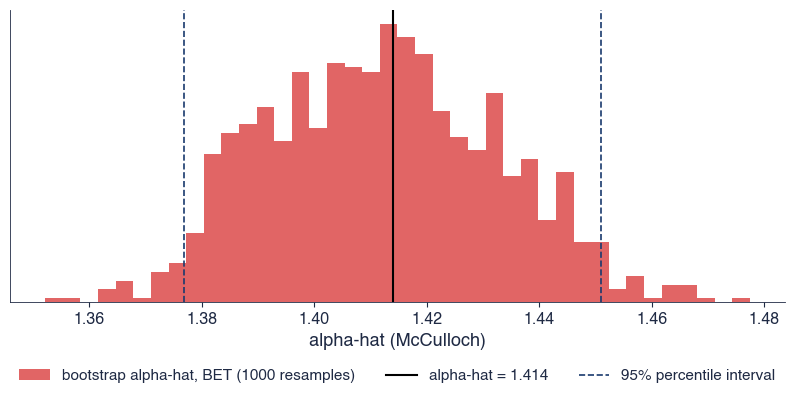

alpha         1.413952
beta          -0.01076
gamma         0.599976
delta0        0.079003
delta1        0.070515
nu_alpha      3.425018
nu_beta      -0.006166
q05           -1.93455
q25          -0.502538
q50           0.077098
q75           0.664942
q95            2.06409
n                 6670
se            0.020501
lo            1.376795
hi            1.451039
first       2000-01-06
last        2026-09-18
dtype: object

In [16]:
# Solution
def b1_mcculloch(name='bet', B=1000, save=True):
    """McCulloch estimates of one series with a bootstrap interval for alpha; chart of the bootstrap draws."""
    r = sem_returns(name)
    m = mcculloch(r.values)
    bs = bootstrap_mcculloch(r.values, B)
    if save is not None:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        ax.hist(bs['draws'], bins=40, color=COLORS[name], alpha=0.6, label=f'bootstrap alpha-hat, {LABELS[name]} ({B} resamples)')
        ax.axvline(m['alpha'], color='black', lw=1.5, label=f"alpha-hat = {m['alpha']:.3f}")
        ax.axvline(bs['lo'], color='#1A3A6E', ls='--', lw=1.2, label='95% percentile interval')
        ax.axvline(bs['hi'], color='#1A3A6E', ls='--', lw=1.2, label='_')
        ax.set_xlabel('alpha-hat (McCulloch)')
        ax.set_yticks([])
        st.legend_outside_bottom(ax, ncol=3, y=-0.18)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch3_sem_b1')
        else:
            plt.show()
    out = {k: v for k, v in m.items()}
    out.update({'n': len(r), 'se': bs['se'], 'lo': bs['lo'], 'hi': bs['hi'], 'first': r.index[0].date().isoformat(),
                'last': r.index[-1].date().isoformat()})
    return out


pd.Series(b1_mcculloch('bet', save=False))

**Interpretation of the result.** α = 2 lies far outside the bootstrap interval: the tails of the BET are much heavier than the Normal distribution allows.

## B2 [Proposed]: three more markets

**Question.** Which of the S&P 500, DAX and Bitcoin has the heaviest tails by McCulloch's method? Model: B1.

1. Repeat steps 1-3 of B1 for each series.
2. Put $\nu_\alpha$, $\hat\alpha$ with its interval, $\hat\beta$ and $\hat\gamma$ of the four series (with the BET) in one table.
3. Interpretation: is the difference between the $\hat\alpha$ of Bitcoin and of the S&P 500 larger than the estimation error?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: maximum likelihood for the S&P 500

**Question.** Does the ML stable fit describe the S&P 500 better than the Normal distribution, in the body and in the tails?

1. Fit the stable law by ML (S0); report $\hat\alpha$ and $\hat\beta$ with standard errors, $\hat\gamma$, $\hat\delta_0$ and $\hat\delta_1$.
2. Compare $\hat\alpha$ with the McCulloch estimate.
3. Fit the Normal and the Student-t distributions and compare the AIC ($2k - 2\ell$) of the three models.
4. Draw the QQ plot of the data against the Normal and the stable fits.
5. Interpretation: where does each model fail?

**Report:** the estimates, three AIC values, the QQ plot and two sentences.

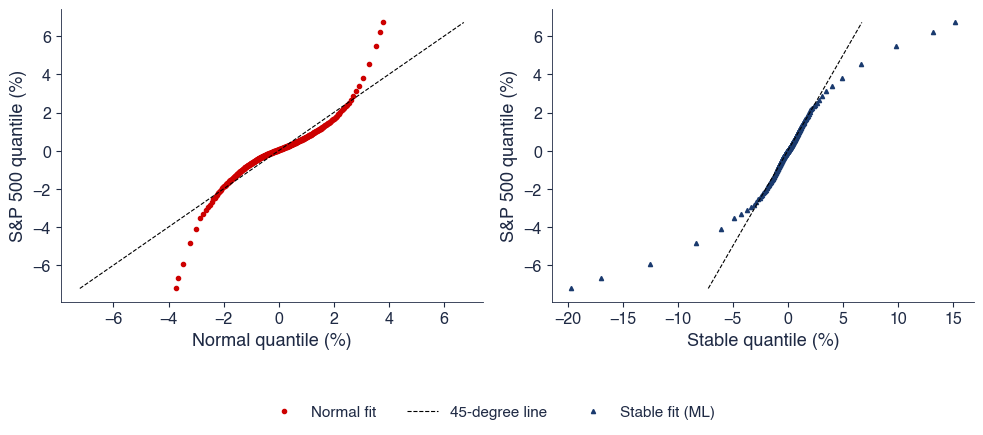

n               6714.000
alpha              1.540
se_alpha           0.021
beta              -0.181
se_beta            0.036
gamma              0.582
delta0             0.093
delta1             0.000
mcc_alpha          1.438
mcc_beta          -0.151
mcc_gamma          0.543
aic_normal     21649.736
aic_t          19702.237
aic_stable     19793.832
t_nu               2.669
q001_emp          -7.222
q001_normal       -3.724
q001_stable      -19.702
dtype: float64

In [18]:
# Solution
def b3_ml(name='sp500', save=True):
    """ML fit of the stable law (S0 and S1 locations), McCulloch for comparison, Normal and Student-t fits; QQ chart."""
    r = sem_returns(name)
    f = fit_models(r.values)
    p = np.concatenate([[0.001, 0.002], (np.arange(1, 400) - 0.5) / 399, [0.998, 0.999]])
    p = np.sort(p[(p > 0) & (p < 1)])
    emp = np.quantile(r.values, p)
    if save is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
        for ax, m, mk in [(axes[0], 'Normal', 'o'), (axes[1], 'Stable', '^')]:
            ax.plot(model_ppf(p, f, m), emp, mk, ms=3, color=MODEL_COL[m], label=f'{m} fit' if m == 'Normal' else 'Stable fit (ML)')
            lim = [emp.min(), emp.max()]
            ax.plot(lim, lim, color='black', lw=0.8, ls='--', label='45-degree line' if m == 'Normal' else '_')
            ax.set_xlabel(f'{m} quantile (%)')
            ax.set_ylabel(f'{LABELS[name]} quantile (%)')
        st.fig_legend_bottom(fig, ncol=3, y=0.0)
        fig.tight_layout(rect=(0, 0.06, 1, 1))
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch3_sem_b3')
        else:
            plt.show()
    s = f['stable']
    return {'n': len(r), 'alpha': s['alpha'], 'se_alpha': s['se_alpha'], 'beta': s['beta'], 'se_beta': s['se_beta'],
            'gamma': s['gamma'], 'delta0': s['delta0'], 'delta1': s['delta1'],
            'mcc_alpha': f['mcculloch']['alpha'], 'mcc_beta': f['mcculloch']['beta'], 'mcc_gamma': f['mcculloch']['gamma'],
            'aic_normal': f['normal']['aic'], 'aic_t': f['t']['aic'], 'aic_stable': s['aic'], 't_nu': f['t']['nu'],
            'q001_emp': float(np.quantile(r.values, 0.001)), 'q001_normal': float(model_ppf(0.001, f, 'Normal')),
            'q001_stable': float(model_ppf(0.001, f, 'Stable'))}


pd.Series(b3_ml('sp500', save=False)).round(3)

**Interpretation of the result.** The Normal fit misses the tails; the stable fit overshoots them; the Student-t has the lowest AIC.

## B4 [Proposed]: large Bitcoin losses under three models

**Question.** Which model reproduces the number of large daily Bitcoin losses best? Model: B3.

1. Fit the Normal, Student-t and stable (ML) laws.
2. Count the days with a loss above 10% and above 20%.
3. Compute the expected number of such days under each model, $n \times P(r < -x)$.
4. Compute VaR 1% of the data and of each model.
5. Interpretation: which model would you use for a margin requirement on a Bitcoin position, and why?

**Report:** one table of counts, four VaR values and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: does α stay the same when returns are summed?

**Question.** If S&P 500 daily returns were i.i.d. stable, weekly and monthly returns would have the same α; do they?

1. Compute the weekly and monthly log returns as sums of the daily ones.
2. Compute the McCulloch $\hat\alpha$ at the three horizons.
3. Bootstrap each $\hat\alpha$ with 500 resamples and report the 95% intervals.
4. Interpretation: is the pattern consistent with i.i.d. stable returns?

**Report:** three estimates with intervals, the chart and two sentences.

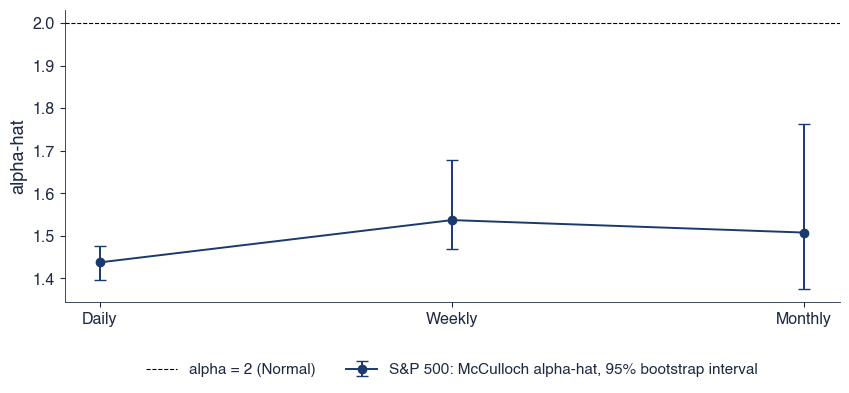

,n,alpha,lo,hi,se
daily,6714.0,1.438,1.396,1.477,0.020
weekly,1394.0,1.537,1.469,1.677,0.053
monthly,321.0,1.508,1.375,1.764,0.100


In [20]:
# Solution
def b5_aggregation(name='sp500', B=500, save=True):
    """McCulloch alpha-hat with bootstrap intervals for daily, weekly and monthly log returns."""
    r = sem_returns(name)
    rows = {}
    for lab, x in [('daily', r), ('weekly', aggregate(r, 'W')), ('monthly', aggregate(r, 'ME'))]:
        m = mcculloch(x.values)
        bs = bootstrap_mcculloch(x.values, B)
        rows[lab] = {'n': len(x), 'alpha': m['alpha'], 'lo': bs['lo'], 'hi': bs['hi'], 'se': bs['se']}
    if save is not None:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        hs = list(rows)
        a = np.array([rows[h]['alpha'] for h in hs])
        lo = np.array([rows[h]['lo'] for h in hs])
        hi = np.array([rows[h]['hi'] for h in hs])
        ax.errorbar(range(3), a, yerr=[a - lo, hi - a], fmt='o-', color=COLORS[name], capsize=4,
                    label=f'{LABELS[name]}: McCulloch alpha-hat, 95% bootstrap interval')
        ax.axhline(2, color='black', ls='--', lw=0.8, label='alpha = 2 (Normal)')
        ax.set_xticks(range(3))
        ax.set_xticklabels(['Daily', 'Weekly', 'Monthly'])
        ax.set_ylabel('alpha-hat')
        st.legend_outside_bottom(ax, ncol=2, y=-0.16)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch3_sem_b5')
        else:
            plt.show()
    return rows


pd.DataFrame(b5_aggregation('sp500', save=False)).T.round(3)

**Interpretation of the result.** α̂ is higher for weekly than for daily returns, a warning sign against i.i.d. stable returns; the monthly sample is too short for a firm answer.

## B6 [Proposed]: does the sample variance settle?

**Question.** Is the sample variance of BET and Bitcoin returns as large and as unstable as a stable law with the fitted α implies? Models: B1, B5.

1. Compute the sample variance of each series over the full sample and over its first half.
2. Simulate 200 paths of the same length from the McCulloch fit (CMS) and compute the sample variance of each path.
3. Report the median and the 5% and 95% percentiles of the simulated variances, and the share below the observed one.
4. Interpretation: what does the comparison say about the infinite-variance hypothesis?

**Report:** a table with two rows and one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: is α constant over time?

**Question.** Do the tails of the BET and the S&P 500 change from one five-year period to the next? Models: B1, B3.

1. Compute the McCulloch $\hat\alpha$ with a bootstrap interval in each period (2000-2004, ..., 2020-2026), for each index.
2. Say which periods differ significantly.
3. Propose one explanation for the changes and one way to test it.
4. Interpretation: what would a changing α mean for a risk model estimated on old data?

**Report:** a table, a short list of significant changes and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant fitted a stable law to the daily S&P 500 log returns (%) since 2000 and claimed:

- (a) scipy's `levy_stable` uses S0 by default, so `loc` is the S0 location;
- (b) the variance of daily returns is $2\gamma^2$;
- (c) the scale of 20-day returns is $\sqrt{20}\,\gamma$;
- (d) since α < 2, the VaR 1% of the model does not exist;
- (e) since α > 1, the mean daily return exists.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** five verdicts with one line of justification each.

In [ ]:
# Your code here
